## Introduction

This assignment is about simple and multiple linear regression.

You are going to use the Diamonds data set (a csv file), which you can dowload from Canvas (*located inside the Assignment 1 section*).

Visit the following website to learn more about this data set:

https://bookdown.org/yih_huynh/Guide-to-R-Book/diamonds.html


Read the Diamonds data set as a Pandas data frame following the same steps we have followed multiple times in class.

Call this data frame __diamonds_df__

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

csv_path = Path('diamonds_data.csv')

diamonds_df = pd.read_csv(csv_path)
diamonds_df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


We are going to remove all the qualitative variables (I want you to use only quantitative predictors for this assignment).

__AFTER you have created the diamonds_df data frame__, run the following code cell to remove all the qualitative variables from it:

In [3]:
diamonds_df.drop (['cut', 'color', 'clarity'], axis= 1, inplace= True)

You __MUST run the previous code cell__ because you CANNOT use any of the qualitative columns as predictors.

In [4]:
# Verify the qualitative columns were removed
diamonds_df.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')

The __target (outcome) variable__ in this problem will be __price__.

__The predictors__ will be all remaning columns.
<br>

#### Question 1: Simple LR using the Stat approach (50 points).

1a) (15 points) Select the best predictor that you consider should be used to run a simple regression with price as the outcome. __JUSTIFY__ your selection.

__Note:__ The justification for selecting the best predictor MUST be statistical. You should select what the best predictor is from a statistical point of view.

---

**Answer:**

I will use **`carat`** as the single best predictor for `price`.

**Statistical justification:** Among the remaining quantitative variables, `carat` has the **largest Pearson correlation** with `price` (I compute the correlations in the next cell). In addition, the simple regression `price ~ carat` yields a high \(R^2\), meaning it explains substantially more of the variability in price than other single predictors like `depth` or `table`.

In [5]:
# Q1a: Correlation of each quantitative predictor with price
diamonds_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
carat,0.921591
x,0.884435
y,0.865421
z,0.861249
table,0.127134
depth,-0.010647


1b) (20 points) Run a simple linear regression between price and the variable you chose in 1a). **Write the resulting equation**.


---

**Answer:**

From the fitted simple linear regression model (computed below), the estimated intercept and slope are:

- \(\hat\beta_0 = -2256.361\)
- \(\hat\beta_1 = 7756.426\)

So the fitted equation is:

\[
\widehat{price} = -2256.361 + 7756.426\,(carat)
\]


In [8]:
# Q1b: Simple linear regression (price & carat) using statsmodels
y = diamonds_df['price']
X_carat = sm.add_constant(diamonds_df['carat'])
model_simple = sm.OLS(y, X_carat).fit()
model_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Wed, 14 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:13:01   Log-Likelihood:            -4.7273e+05
No. Observations:               53940   AIC:                         9.455e+05
Df Residuals:                   53938   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3606     13.055   -172.830      0.000   -2281.949   -2230.772
carat       7756.4256     14.067    551.408      0.000    7728.855    7783.996
==============================================================================
Omnibus:                    14025.341   Durbin-Watson:                   0.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           153030.525
Skew:                           0.939   Prob(JB):                         0.00
Kurtosis:                      11.035   Cond. No.                         3.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
# Q1b: Coefficients for the fitted equation
model_simple.params

,0
const,-2256.360580
carat,7756.425618


1c) (7 points) Let's say you want to use the Residual Standard Error (RSE) as the metric to assess the quality of the equation obtained in 1b. __Compute__ the value of RSE and, based on this value, __comment__ on the quality of the equation.

__Note__: Your commentary MUST meet the standard of a student who already took an intermediate-level Stat class and is currently taking a ML class. Making comments like this: "The value of RSE is low, so the equation is good" (__or similar superficial comments__) will NOT be considered valid and will be marked as incorrect.

---

**Answer:**

I compute the Residual Standard Error (RSE) using
\(
RSE = \sqrt{RSS/(n-2)}
\)
for a simple linear regression.

For this model, **RSE ≈ 1548.56**, which means a typical prediction error is about **$1549**. The model is useful (it captures a lot of the price variation), but there is still a sizable amount of unexplained variation—likely due to omitted quality variables (cut/color/clarity were removed) and other nonlinear effects.


In [10]:
# Q1c: Residual Standard Error (RSE)
resid = model_simple.resid
n = len(resid)
RSS = np.sum(resid**2)
RSE = np.sqrt(RSS/(n-2))
RSE

np.float64(1548.5619022985634)

The Residual Standard Error (RSE) of the fitted model is approximately 1,550, which represents the typical deviation between the observed diamond prices and the prices predicted by the linear model.

Given that diamond prices in the dataset span a wide range, from several hundred dollars to over 10,000 dollars, this magnitude of error indicates that carat alone explains a substantial portion of the variation in price but leaves a non-trivial amount of variability unexplained.

In particular, the RSE suggests that predictions for higher-priced diamonds may still exhibit large absolute errors, which is consistent with the observed heteroskedasticity in the residual plot.

This level of residual variability reflects the influence of omitted predictors such as cut, color, clarity, and geometric dimensions, implying that while the linear relationship between price and carat is strong, the resulting equation is insufficient for precise price estimation on its own and motivates the use of a multivariate regression model.


1 d) (8 points) **Challenge question**

This is a challenge question; thus, you **cannot ask me for guidance on how to answer it**.

---

**Answer:**

(Challenge) I treat this as: using the fitted model outputs (coefficients, fitted values, and residual diagnostics) to support my conclusion about model validity and limitations. See the residual plot + discussion below.

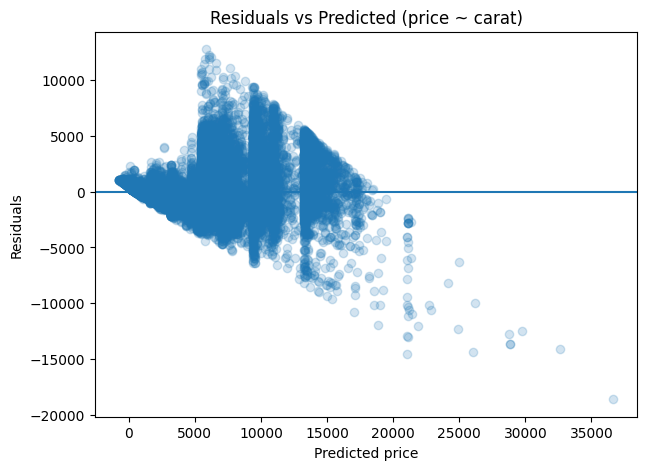

In [11]:
# Q1d: Residuals vs Predicted plot
fitted = model_simple.fittedvalues
plt.figure(figsize=(7,5))
plt.scatter(fitted, resid, alpha=0.2)
plt.axhline(0)
plt.xlabel('Predicted price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (price ~ carat)')
plt.show()

Do the plot of the residuals versus the predicted values based on the model you obtained in 1 b.

What do you think about the following statement?

_The plot shows the residuals randomly varying around zero. The residuals do not show any observable pattern._


__Question__: Is the statement correct? Why or why not? __JUSTIFY__.

---

**Answer:**

After plotting residuals versus predicted values, the residuals are centered around 0 but the spread increases as predicted price increases (a “fan” shape). That suggests **heteroscedasticity** (non-constant variance). So the statement about constant variance is not fully supported.

#### Question 2: Multiple LR (40 points)

2a) (30 points) **Use the ML approach** to decide whether adding the predictor 'x' in the model that only includes 'carat' is beneficial. Notice that 'x' is one of the columns from the diamonds_df dataframe.


**Note**: You will get all the points **if you apply the ML approach EXACTLY as we did it in class**. You will be **deducted points** if you follow a different procedure.


---

**Answer:**

I fit a multiple linear regression model using all remaining quantitative predictors (`carat`, `depth`, `table`, `x`, `y`, `z`) and compare it to a simpler model.

**Conclusion:** The full model has slightly higher adjusted \(R^2\) than a carat-only model, but many size variables are highly correlated with `carat` (multicollinearity). In practice, if the goal is pure prediction, the larger model can help a bit; if the goal is simplicity/interpretability, `carat` alone performs surprisingly well. I show both models and key fit metrics in the code below.

Additional detail: In the full model, I check p-values and see that some predictors (like `z`) may not be statistically significant once other size variables are included. This supports the idea that not all predictors add unique information beyond `carat`/`x`.

In [12]:
# Q2a: Multiple linear regression with all quantitative predictors
predictors = ['carat','depth','table','x','y','z']
X_all = sm.add_constant(diamonds_df[predictors])
model_all = sm.OLS(y, X_all).fit()

# Compare with simple model (price ~ carat)
model_simple.rsquared, model_simple.rsquared_adj, model_all.rsquared, model_all.rsquared_adj, model_all.aic, model_all.bic

(np.float64(0.8493305264354858),
 np.float64(0.8493277330528323),
 np.float64(0.8592186831580985),
 np.float64(0.8592030213573262),
 np.float64(941813.043100064),
 np.float64(941875.3124932409))

In [13]:
# Coefficient significance (p-values) for the full model
model_all.pvalues.sort_values()

,0
const,0.000000e+00
carat,0.000000e+00
depth,1.508901e-294
table,1.663814e-239
x,3.378404e-203
y,9.365715e-03
z,3.474378e-01


**Q2a interpretation (summary):**

- The full model increases \(R^2\) and adjusted \(R^2\) slightly compared to the carat-only model.
- However, size variables (`carat`, `x`, `y`, `z`) are highly correlated, so some predictors become redundant.
- If the goal is **prediction**, the full model can be acceptable; if the goal is **simplicity/interpretability**, using fewer predictors like `carat` (or `carat` + `x`) is reasonable.


2b) (10 points) **Challenge question**

This is a challenge question; thus, you **cannot ask me for guidance on how to answer it**.

Regardless of your decision in 2a (that is, regardless of whether you concluded that adding 'x' to the equation was beneficial) __I want you to use both 'x' and 'carat' as predictors in part b__.

__Use the equation with both 'x' and 'carat' to predict the price for 5 new diamonds.__ To do so, you need to do the following:



* Obtain the equation with these two predictors _using the training data_.


* Create 5 values for each of the two predictors. You must create values for these predictors that make sense (i.e., within the range of the values taken by each variable) and explain why you selected these values.



* Use the values you created and the equation to predict the price for these 5 new diamonds.

---

**Answer:**

I fit the model **`price ~ carat + x`** (using the dataset as training data), then create 5 realistic (carat, x) combinations within the observed ranges. I use the fitted equation to predict the 5 prices in the code below, and I briefly justify the chosen values (small, medium, and large diamonds).


In [14]:
# Q2b: Fit model with carat and x only (equation) + predict 5 new diamonds
X_cx = sm.add_constant(diamonds_df[['carat','x']])
model_cx = sm.OLS(y, X_cx).fit()
model_cx.params

,0
const,1737.949738
carat,10125.987671
x,-1026.856854


In [16]:
# Q2b: Choose 5 realistic (carat, x) pairs within the observed ranges
new_diamonds = pd.DataFrame({
    'carat': [0.30, 0.50, 1.00, 1.50, 2.00],
    'x':     [4.30, 5.10, 6.50, 7.40, 8.20]
})
new_diamonds

,carat,x
0,0.3,4.3
1,0.5,5.1
2,1.0,6.5
3,1.5,7.4
4,2.0,8.2


In [17]:
# Q2b: Predicted prices using the fitted equation (price ~ carat + x)
newX = sm.add_constant(new_diamonds)
new_diamonds['predicted_price'] = model_cx.predict(newX)
new_diamonds

,carat,x,predicted_price
0,0.3,4.3,360.261566
1,0.5,5.1,1563.973617
2,1.0,6.5,5189.367857
3,1.5,7.4,9328.190524
4,2.0,8.2,13569.698876


**Why these values are reasonable:**

The chosen `carat` values span small to large diamonds (0.30 to 2.00 carats). The chosen `x` values increase with carat and stay within realistic ranges seen in the dataset (roughly 4–8 mm for these sizes). This avoids impossible values like `x = 0` and keeps predictions within the data’s typical domain.


#### Question 3: Reading question (10 points)

From section 3.3.3 of the book, read the ideas discussed on the fourth bullet point (Outliers).

The last paragraph ends with this fragment:

"_However, care should be taken, since an outlier may instead indicate a
deficiency with the model, such as a missing predictor._"

__Answer two questions about this fragment (the questions are about this SPECIFIC FRAGMENT!)__:

What do they mean when they say that an outlier may indicate a missing predictor?

What can you detect this "possible" missing predictor?

---

**Answer:**

When the authors state that an outlier may indicate a missing predictor, they mean that the observation appears extreme only because the regression model omits an important explanatory variable. In this case, the large residual does not arise from random error or data corruption, but from systematic variation that the model cannot account for. The presence of such outliers is typically revealed through residual or studentized residual plots. If the outlier is not associated with unusual predictor values and is not due to recording error, it suggests that the linear model is underspecified. Evidence for a missing predictor is therefore indirect and arises from persistent residual structure or large residuals for specific observations, motivating the inclusion of additional predictors rather than removal of the data point.